In [1]:
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
# Load cleaned dataset
data = pd.read_csv("../data/mobixa_intents_clean.csv")



data.head()

,text,intent,response,lowercase,no_punctuation,tokens,no_stopwords,stemmed,lemmatized,processed_text
0,Catch you later,goodbye,Response for goodbye.,catch you later,catch you later,"['catch', 'you', 'later']","['catch', 'later']","['catch', 'later']","['catch', 'later']",catch later
1,Hi,greeting,Response for greeting.,hi,hi,['hi'],['hi'],['hi'],['hi'],hi
2,Good morning,greeting,Response for greeting.,good morning,good morning,"['good', 'morning']","['good', 'morning']","['good', 'morn']","['good', 'morning']",good morning
3,Cost of Redmi Note 14,price_query,Response for price_query.,cost of redmi note 14,cost of redmi note 14,"['cost', 'of', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']",cost redmi note 14
4,Availability of Galaxy S24,availability,Response for availability.,availability of galaxy s24,availability of galaxy s24,"['availability', 'of', 'galaxy', 's24']","['availability', 'galaxy', 's24']","['avail', 'galaxi', 's24']","['availability', 'galaxy', 's24']",availability galaxy s24


In [3]:
with open("../models/tfidf_vectorizer.pkl","rb") as file:
    tfidf = pickle.load(file)



In [4]:
X = tfidf.transform(data["processed_text"])

y = data["intent"]

print(X.shape)
print(y.shape)

(1000, 76)
(1000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [6]:
print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 800
Testing Samples : 200


In [7]:
svm_model = SVC(kernel="linear")

svm_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
predictions = svm_model.predict(X_test)

print(predictions[:10])

['price_query' 'greeting' 'thanks' 'recommendation' 'recommendation'
 'price_query' 'goodbye' 'phone_search' 'thanks' 'price_query']


In [9]:
accuracy = accuracy_score(

    y_test,

    predictions

)

print("Accuracy :", accuracy)

Accuracy : 0.985


In [10]:
accuracy = accuracy_score(

    y_test,

    predictions

)

print("Accuracy :", accuracy)

Accuracy : 0.985


In [11]:
print(classification_report(

    y_test,

    predictions

))

                  precision    recall  f1-score   support

accessory_search       1.00      1.00      1.00        23
    availability       1.00      0.83      0.91        18
      comparison       0.87      1.00      0.93        20
         goodbye       1.00      1.00      1.00        20
        greeting       1.00      1.00      1.00        20
         payment       1.00      1.00      1.00        21
    phone_search       1.00      1.00      1.00        19
     price_query       1.00      1.00      1.00        21
  recommendation       1.00      1.00      1.00        19
          thanks       1.00      1.00      1.00        19

        accuracy                           0.98       200
       macro avg       0.99      0.98      0.98       200
    weighted avg       0.99      0.98      0.98       200



In [12]:
cm = confusion_matrix(

    y_test,

    predictions

)

print(cm)

[[23  0  0  0  0  0  0  0  0  0]
 [ 0 15  3  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0]
 [ 0  0  0  0  0 21  0  0  0  0]
 [ 0  0  0  0  0  0 19  0  0  0]
 [ 0  0  0  0  0  0  0 21  0  0]
 [ 0  0  0  0  0  0  0  0 19  0]
 [ 0  0  0  0  0  0  0  0  0 19]]


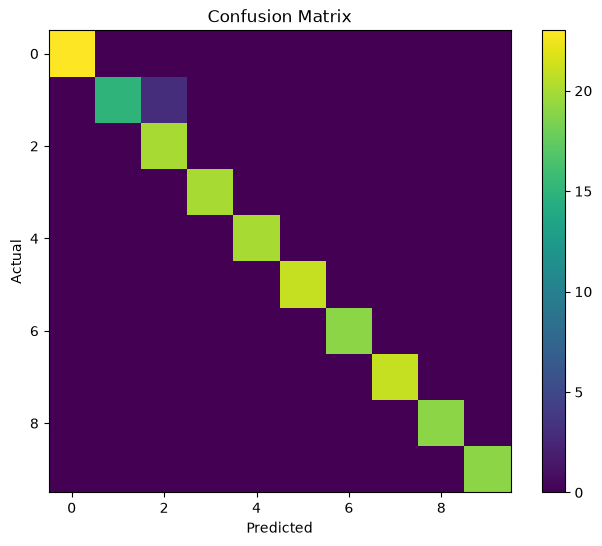

In [13]:
plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [14]:
with open("../models/intent_classifier_ml.pkl","wb") as file:

    pickle.dump(svm_model,file)

print("ML Model Saved Successfully")

ML Model Saved Successfully


In [15]:
new_text = [

    "What is the price of Samsung Galaxy S24?"

]

new_vector = tfidf.transform(new_text)

prediction = svm_model.predict(new_vector)

print("Predicted Intent :", prediction[0])

Predicted Intent : price_query


In [16]:
examples = [

    "Hello",

    "Do you repair iPhones?",

    "Compare Samsung and iPhone",

    "Do you have AirPods?",

    "Bye"

]

vectors = tfidf.transform(examples)

predictions = svm_model.predict(vectors)

for sentence,intention in zip(examples,predictions):

    print(sentence," ---> ",intention)

Hello  --->  greeting
Do you repair iPhones?  --->  phone_search
Compare Samsung and iPhone  --->  comparison
Do you have AirPods?  --->  accessory_search
Bye  --->  goodbye
